In [296]:
from pathlib import Path
import os

import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

In [74]:
src_root = (Path('..') / 'src').resolve()
os.chdir(src_root)

from mihms.prep import prms as pprms
from mihms.models.models import PrmsModel

from mihms.output import PrmsOutput
from mihms.prep.utils import write_prms_datafile

In [192]:
m_wd = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/streamflow_calibration')
gmet_srad_pth = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/gridmet_srad_prmsgrid.nc')
gmet_sradcf_pth = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/prms_solrad_corrections.nc')
prms_grid_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/prms/UY_prms_nolakes_grid.shp')
gage_pourpnt_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/Vector/prms_subbasin_pourpnts.shp')
obs_data_pth = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/calibration_data/gage_observation_data.csv')

In [193]:
ppnts = gpd.read_file(gage_pourpnt_pth)
obsdat = pd.read_csv(obs_data_pth)
prmsgrid = gpd.read_file(prms_grid_pth)

In [17]:
ppnts.iloc[:-1,:]

,Id,name,station_id,geometry
0,0,Yellowstone Headwaters,06186500,POINT (-1134684.54 2484462.273)
1,0,Lamar River,06188000,POINT (-1130586.245 2523516.803)
2,0,Gardner River,06191000,POINT (-1152573.178 2534220.04)
3,0,Bear Creek,43B 89500,POINT (-1146655.295 2541916.245)
4,0,Pine Creek Bear Creek,43B 89480,POINT (-1145706.34 2542665.867)
5,0,Mulherin Creek,43B 91550,POINT (-1159089.505 2550437.534)
6,0,Cedar Creek,43B 91620,POINT (-1158974.748 2552225.088)
7,0,Tom Miner Creek,43B 01990,POINT (-1165613.048 2559246.856)
8,0,Rock Creek,43B 91750,POINT (-1165126.918 2560793.507)
9,0,Big Creek,43B 91820,POINT (-1159115.381 2570326.308)


In [194]:
obds = pprms.domain.create_obs_dataset(obsdat, ppnts.iloc[:-1,:], 'station_id', prmsgrid)

In [152]:
obds

<xarray.Dataset>
Dimensions:           (time: 1827, location: 18)
Coordinates:
    lon               (location) float64 -110.4 -110.4 -110.7 ... -110.6 -110.8
    lat               (location) float64 44.58 44.93 44.99 ... 45.56 45.6 45.11
    hru               (location) int64 43981 39581 11130 ... 23242 18621 31384
  * location          (location) object '06186500' '06188000' ... '06191500'
  * time              (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
    subbasin          (location) int32 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
    segment           (location) int32 400 157 133 1241 ... 954 1218 1086 522
Data variables:
    observation_data  (time, location) float64 374.0 155.0 110.0 ... 87.51 411.0
Attributes:
    description:  Observation data associated with PRMS model domain.

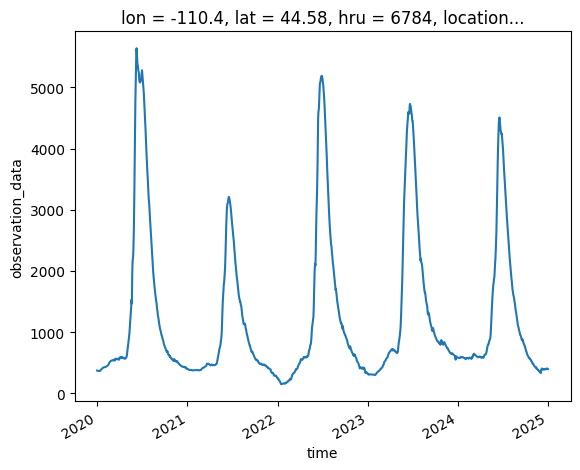

In [7]:
obds.observation_data.isel(location=0).plot()

In [22]:
et_conv = et.actual_et.sel(hru=25501) / 25.4

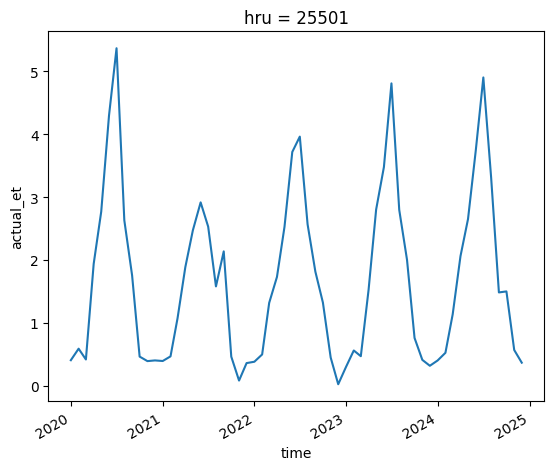

In [24]:
et_conv.plot()

In [195]:
prmscont = pprms.CreateControlFile(prms_exe=Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'),
                               prms_version='6.0.0',
                               start_time='2018-01-01',
                               end_time='2024-12-31',
                               data_files=m_wd / 'UY_1979_2024.data',
                               param_files=m_wd / 'UY_nolake_params.param',
                               output_path=m_wd,
                               file_name='UY_sub_nolake_streamflow.control')
prmscont.select_output_variables(['subinc_gwflow', 'sub_cfs', 'sub_inq'])
#prmscont.add_statvars('hru_actet', 25501)

In [31]:
prmscont.control_obj._records_list

[start_time,
 end_time,
 executable_model,
 executable_desc,
 model_output_file,
 csv_output_file,
 param_file,
 data_file,
 model_mode,
 cascade_flag,
 cascadegw_flag,
 et_module,
 precip_module,
 snarea_curve_flag,
 soilzone_aet_flag,
 solrad_module,
 srunoff_module,
 strmflow_module,
 temp_module,
 transp_module,
 csvON_OFF,
 subbasin_flag,
 nsubOutON_OFF,
 nsubOut_format,
 nsubOut_freq,
 nsubOutBaseFileName,
 nsubOutVar_names,
 nsubOutVars]

In [196]:
prmscont.save_controlfile()

In [197]:
prms_mod = PrmsModel(prmscont)

------------------------------------
Reading parameter file : UY_nolake_params.param
------------------------------------


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [198]:
prms_mod.parameters.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nssr: 46199, ngw: 46199, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw, ndeplval
Data variables: (12/108)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    melt_look             (nhru) int32 90 90 90 90 90 90 ... 90 90 90 90 90 90
    settle_const          (nhru) float64 0.1 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    snarea_thresh         (nhru) float64 50.0 50.0 50.0 50.0 ... 50.0 50.0 50.0
    cecn_coef             (nmonths, nhru) float64 5.0 5.0 5.0 ... 5.0 5.0 5.0
    tstorm_mo             (nmonths, nhru) int32 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [57]:
prms_mod.parameters.change_parameter(name='dday_intcp', values=-20.0)
prms_mod.parameters.change_parameter(name='dday_slope', values=0.9)

In [58]:
prms_mod.parameters.select_parameters('dday_slope')

<xarray.DataArray 'dday_slope' (nmonths: 12, nhru: 45244)>
array([[0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9],
       [0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9],
       [0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9],
       ...,
       [0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9],
       [0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9],
       [0.9, 0.9, 0.9, ..., 0.9, 0.9, 0.9]])
Dimensions without coordinates: nmonths, nhru
Attributes:
    default:    0.4
    desc:       Slope in temperature degree-day relationship
    help:       Monthly (January to December) slope in degree-day equation fo...
    maximum:    1.4
    minimum:    0.1
    modules:    ['ddsolrad']
    type:       F
    units:      dday/temp_units
    dims:       ('nmonth', 'nhru')
    file_name:  D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/solrad_cal...

In [59]:
prms_mod.parameters.write_paramfile()

In [199]:
prms_mod.run_model(silent=False,report=True)



                         U.S. Geological Survey
               Precipitation-Runoff Modeling System (PRMS)
                        Version 6.0.0 02/01/2025

--------------------------------------------------------------------
        Process            Available Modules
--------------------------------------------------------------------
  Basin Definition: basin
    Cascading Flow: cascade
  Time Series Data: obs, water_use_read, dynamic_param_read
                    dynamic_soil_param_read
   Potet Solar Rad: soltab
  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,
                    temp_map
       Precip Dist: precip_1sta, precip_laps, precip_dist2,
                    climate_hru, precip_map
Temp & Precip Dist: xyz_dist, ide_dist
    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru
Transpiration Dist: transp_tindex, climate_hru, transp_frost
      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,
                    potet_hs, potet_pt, potet_pm, pote

(True,
 ['',
  '',
  '                         U.S. Geological Survey',
  '               Precipitation-Runoff Modeling System (PRMS)',
  '                        Version 6.0.0 02/01/2025',
  '',
  '--------------------------------------------------------------------',
  '        Process            Available Modules',
  '--------------------------------------------------------------------',
  '  Basin Definition: basin',
  '    Cascading Flow: cascade',
  '  Time Series Data: obs, water_use_read, dynamic_param_read',
  '                    dynamic_soil_param_read',
  '   Potet Solar Rad: soltab',
  '  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,',
  '                    temp_map',
  '       Precip Dist: precip_1sta, precip_laps, precip_dist2,',
  '                    climate_hru, precip_map',
  'Temp & Precip Dist: xyz_dist, ide_dist',
  '    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru',
  'Transpiration Dist: transp_tindex, climate_hru, transp_frost',
  '      

In [ ]:
output = PrmsOutput(prmscont, obs_dset=obds)
subout = output.get_subbasin_output()
subout = subout.sel(time=slice('2020-01-01', '2024-12-31'))

In [201]:
subout = output.get_subbasin_output()

In [ ]:
subout = subout.sel(time=slice('2020-01-01', '2024-12-31'))

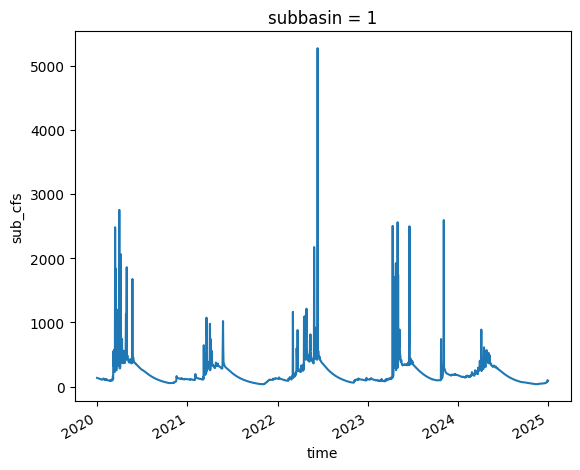

In [204]:
subout.sub_cfs.sel(subbasin=1).plot()

In [318]:
subbsn = 17
loc = obds.location[obds.subbasin == subbsn]
strm = obds.observation_data.sel(location=loc.values)
mod = subout.sub_cfs.sel(subbasin=subbsn)
mod2 = subout.sub_cfs.sel(subbasin=subbsn)

In [319]:
strm_df = strm.to_dataframe()
strm_df = strm_df.droplevel(1)
strm_s = strm_df['observation_data']
strm_m = strm_s.groupby([strm_s.index.month, strm_s.index.day]).median()
strm_10 = strm_s.groupby([strm_s.index.month, strm_s.index.day]).quantile(q=0.1)
strm_90 = strm_s.groupby([strm_s.index.month, strm_s.index.day]).quantile(q=0.9)
strm_m.index = pd.date_range('2020-01-01', '2020-12-31')
strm_10.index = pd.date_range('2020-01-01', '2020-12-31')
strm_90.index = pd.date_range('2020-01-01', '2020-12-31')

mod_df = mod.to_dataframe()
mod_s = mod_df['sub_cfs']
mod_m = mod_s.groupby([mod_s.index.month, mod_s.index.day]).median()
mod_10 = mod_s.groupby([mod_s.index.month, mod_s.index.day]).quantile(q=0.1)
mod_90 = mod_s.groupby([mod_s.index.month, mod_s.index.day]).quantile(q=0.9)
mod_m.index = pd.date_range('2020-01-01', '2020-12-31')
mod_10.index = pd.date_range('2020-01-01', '2020-12-31')
mod_90.index = pd.date_range('2020-01-01', '2020-12-31')

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\xarray\core\dataset.py:6257: DeprecationWarning: `cumproduct` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `cumprod` instead.
  index = self.coords.to_index([*ordered_dims])


In [323]:
all_UY_flow = pd.read_csv('C:/Users/CNB968/OneDrive - MT/Yellowstone/Upper Yellowstone/UY_ImputedStreamflow_Final.csv')
corwin = all_UY_flow.set_index(pd.DatetimeIndex(obsdat['Date']))['X06191500']
strm_s = corwin
strm_m = strm_s.groupby([strm_s.index.month, strm_s.index.day]).median()
strm_10 = strm_s.groupby([strm_s.index.month, strm_s.index.day]).quantile(q=0.1)
strm_90 = strm_s.groupby([strm_s.index.month, strm_s.index.day]).quantile(q=0.9)
strm_m.index = pd.date_range('2020-01-01', '2020-12-31')
strm_10.index = pd.date_range('2020-01-01', '2020-12-31')
strm_90.index = pd.date_range('2020-01-01', '2020-12-31')

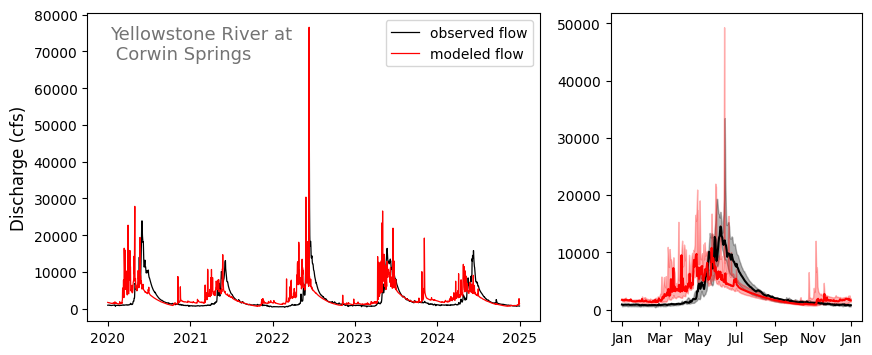

In [327]:
import matplotlib.pyplot as plt
month_format = DateFormatter("%b")

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), width_ratios=[1.8,1])
ax[0].plot(strm_s.index, strm_s, marker=None, ls='-', lw=0.9, color='black', label='observed flow')
ax[0].plot(mod_s.index, mod_s, marker=None, ls='-', lw=0.9, color='red', label='modeled flow')
ax[1].plot(strm_m.index, strm_m, marker=None, ls='-', color='black')
ax[1].plot(mod_m.index, mod_m, marker=None, ls='-', color='red')
ax[1].fill_between(strm_10.index, strm_10, strm_90, color='black', alpha=0.3)
ax[1].fill_between(mod_10.index, mod_10, mod_90, color='red', alpha=0.3)
ax[1].xaxis.set_major_formatter(month_format)
ax[0].text(0.05, 0.85, "Yellowstone River at\n Corwin Springs", fontsize=13, alpha=0.55, transform=ax[0].transAxes)
ax[0].set_ylabel('Discharge (cfs)', fontsize=12)
ax[0].legend()

In [329]:
indat = prms_mod.data.data_df

In [330]:
indat[indat['Year'] == 2024]

,Year,Month,Day,Hour,Minute,Second,tmax_0,tmax_1,tmax_2,tmax_3,...,precip_96,precip_97,precip_98,precip_99,precip_100,precip_101,precip_102,precip_103,runoff_0,Date
16436,2024,1,1,0,0,0,1.150007,1.305566,3.772227,4.716675,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,584.000000,2024-01-01
16437,2024,1,2,0,0,0,2.105564,2.761119,6.105567,7.361118,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,582.000000,2024-01-02
16438,2024,1,3,0,0,0,1.850006,2.183343,4.150007,4.994449,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,580.000000,2024-01-03
16439,2024,1,4,0,0,0,-0.027774,-0.061103,2.583337,3.638892,...,1.677778,1.666667,1.688889,0.966667,1.622222,1.577778,1.133333,0.077778,578.000000,2024-01-04
16440,2024,1,5,0,0,0,-1.094435,-1.161106,2.094452,3.083340,...,1.822222,1.422222,1.122222,0.733333,1.588889,1.222222,0.700000,0.111111,579.000000,2024-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16797,2024,12,27,0,0,0,0.750003,1.338901,5.094449,6.650007,...,6.488889,5.544445,4.388889,2.988889,4.977778,3.866667,2.600000,1.933333,373.533981,2024-12-27
16798,2024,12,28,0,0,0,2.427785,2.983334,6.605557,7.972226,...,10.477777,11.022222,10.733334,11.000000,10.888888,9.777779,8.677777,9.855556,375.155340,2024-12-28
16799,2024,12,29,0,0,0,2.805566,2.405558,3.594449,3.905558,...,24.311110,24.433334,23.311111,20.533333,22.822222,20.622221,17.944445,17.722225,376.776699,2024-12-29
16800,2024,12,30,0,0,0,-3.372220,-3.727770,-1.461110,-0.805545,...,1.666667,2.333333,2.677778,2.555556,2.377778,2.211111,1.955556,1.666667,378.398058,2024-12-30


In [484]:
from gsflow import PrmsData
data = PrmsData.load_from_file(m_wd / 'UYnolake_1979_2025.data')

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [379]:
data.data_df['tmin_0']

0       -17.527771
1       -10.983327
2        -8.927775
3       -13.249990
4       -14.449988
           ...    
16797     0.750003
16798     2.427785
16799     2.805566
16800    -3.372220
16801    -4.816660
Name: tmin_0, Length: 16802, dtype: float64

In [361]:
dat_an = data.data_df.groupby(['Year']).mean()

In [364]:
tmax_avg = dat_an.iloc[:,5:109].mean(axis=1)
tmin_avg = dat_an.iloc[:,109:213].mean(axis=1)
pr_avg = dat_an.iloc[:,213:317].mean(axis=1)
all_avg = pd.concat([tmax_avg, tmin_avg, pr_avg], axis=1)

In [367]:
tmin_avg

Year
1979    7.967207
1980    8.131165
1981    8.970822
1982    6.489988
1983    7.733837
1984    7.239028
1985    7.078631
1986    8.390515
1987    9.321949
1988    9.317051
1989    7.666354
1990    7.885101
1991    7.969738
1992    8.553207
1993    6.655763
1994    8.581267
1995    7.600767
1996    7.552148
1997    7.739691
1998    8.371027
1999    8.826052
2000    8.657112
2001    9.270435
2002    7.712414
2003    9.024032
2004    8.417575
2005    8.813898
2006    9.076644
2007    9.479667
2008    8.086435
2009    8.157578
2010    8.479332
2011    7.426667
2012    9.489942
2013    7.944253
2014    8.225070
2015    9.751528
2016    9.366115
2017    8.864432
2018    8.526224
2019    7.493580
2020    8.589966
2021    9.313325
2022    8.404068
2023    8.297861
2024    9.124087
2025   -1.313088
dtype: float64

In [365]:
all_avg

,0,1,2
Year,,,
1979,7.967207,7.967207,1.707373
1980,8.131165,8.131165,2.379953
1981,8.970822,8.970822,2.244864
1982,6.489988,6.489988,2.580925
1983,7.733837,7.733837,2.409031
1984,7.239028,7.239028,2.246072
1985,7.078631,7.078631,1.952332
1986,8.390515,8.390515,2.344163
1987,9.321949,9.321949,1.687089


In [381]:
all_avg.mean()

0    8.142989
1    8.142989
2    2.179150
dtype: float64

WW = 2017
WD = 1987
CW = 2019
CD = 2002
NORM = 2009

In [485]:
year = 2009
d = data.data_df.copy()
d['Index'] = d.index
d = d.set_index(pd.DatetimeIndex(d['Date']))
idx = d.loc[f'{year}-04-02': f'{year}-09-30', 'Index']
new_met = data.data_df.loc[idx.to_list(),:]
new_met['Year'] = 2025
new_dat = pd.concat([data.data_df, new_met])

In [486]:
data.data_df = new_dat

In [487]:
write_prms_datafile(data, m_wd / 'UY_forecast_norm.data')

In [488]:
forccont = pprms.CreateControlFile(prms_exe=Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'),
                               prms_version='6.0.0',
                               start_time='2018-01-01',
                               end_time='2025-09-30',
                               data_files=m_wd / 'UY_forecast_norm.data',
                               param_files=m_wd / 'UY_nolake_params.param',
                               output_path=m_wd,
                               file_name='UY_forecast.control')
forccont.select_output_variables(['subinc_gwflow', 'sub_cfs', 'sub_inq'])

In [489]:
forccont.save_controlfile()

In [490]:
forc_mod = PrmsModel(forccont)

------------------------------------
Reading parameter file : UY_nolake_params.param
------------------------------------


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [491]:
forc_mod.data.data_df

,Year,Month,Day,Hour,Minute,Second,tmax_0,tmax_1,tmax_2,tmax_3,...,precip_96,precip_97,precip_98,precip_99,precip_100,precip_101,precip_102,precip_103,runoff_0,Date
0,1979,1,1,0,0,0,-17.527771,-17.505548,-16.427774,-16.227774,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,370.0,1979-01-01
1,1979,1,2,0,0,0,-10.983327,-11.116665,-10.227773,-10.172217,...,1.077778,0.433333,0.233333,0.077778,0.677778,0.122222,0.000000,0.000000,360.0,1979-01-02
2,1979,1,3,0,0,0,-8.927775,-8.883327,-7.794440,-7.961103,...,6.955557,6.544445,5.933333,5.666667,11.277778,10.711111,6.066668,5.322222,350.0,1979-01-03
3,1979,1,4,0,0,0,-13.249990,-13.216658,-12.116658,-12.005550,...,7.377778,9.788889,12.555555,11.988890,3.877778,6.655556,13.044445,11.488890,350.0,1979-01-04
4,1979,1,5,0,0,0,-14.449988,-13.983327,-12.438887,-11.372216,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,360.0,1979-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17070,2025,9,26,0,0,0,23.305559,23.238899,25.738899,26.772226,...,0.411111,0.577778,0.688889,0.888889,0.066667,0.311111,0.866667,0.977778,1110.0,2025-09-26
17071,2025,9,27,0,0,0,15.438890,15.405561,17.883341,18.883339,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1080.0,2025-09-27
17072,2025,9,28,0,0,0,22.550009,22.505562,24.972229,25.405561,...,0.177778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1050.0,2025-09-28
17073,2025,9,29,0,0,0,23.716679,23.772226,26.350010,27.538893,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1030.0,2025-09-29


In [492]:
forc_mod.run_model()



                         U.S. Geological Survey
               Precipitation-Runoff Modeling System (PRMS)
                        Version 6.0.0 02/01/2025

--------------------------------------------------------------------
        Process            Available Modules
--------------------------------------------------------------------
  Basin Definition: basin
    Cascading Flow: cascade
  Time Series Data: obs, water_use_read, dynamic_param_read
                    dynamic_soil_param_read
   Potet Solar Rad: soltab
  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,
                    temp_map
       Precip Dist: precip_1sta, precip_laps, precip_dist2,
                    climate_hru, precip_map
Temp & Precip Dist: xyz_dist, ide_dist
    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru
Transpiration Dist: transp_tindex, climate_hru, transp_frost
      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,
                    potet_hs, potet_pt, potet_pm, pote

(True,
 ['',
  '',
  '                         U.S. Geological Survey',
  '               Precipitation-Runoff Modeling System (PRMS)',
  '                        Version 6.0.0 02/01/2025',
  '',
  '--------------------------------------------------------------------',
  '        Process            Available Modules',
  '--------------------------------------------------------------------',
  '  Basin Definition: basin',
  '    Cascading Flow: cascade',
  '  Time Series Data: obs, water_use_read, dynamic_param_read',
  '                    dynamic_soil_param_read',
  '   Potet Solar Rad: soltab',
  '  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,',
  '                    temp_map',
  '       Precip Dist: precip_1sta, precip_laps, precip_dist2,',
  '                    climate_hru, precip_map',
  'Temp & Precip Dist: xyz_dist, ide_dist',
  '    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru',
  'Transpiration Dist: transp_tindex, climate_hru, transp_frost',
  '      

In [493]:
forout = PrmsOutput(forccont, obs_dset=obds)
subout = forout.get_subbasin_output()
subout = subout.sel(time=slice('2020-01-01', None))

In [494]:
df = subout.sub_cfs.sel(subbasin=3, time=slice('2025-01-01', None)).to_dataframe()

In [495]:
df.to_csv(m_wd / 'MillCr_NORM_Ensemble.csv')

In [497]:
forecast = pd.read_csv(m_wd / 'MillCr_Ensembles.csv', parse_dates=True, index_col=0)

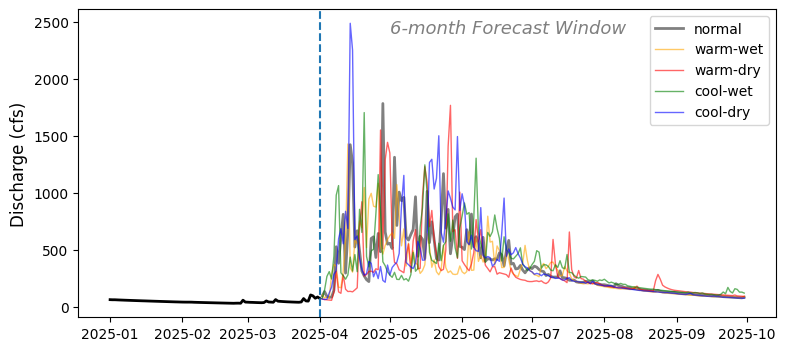

In [544]:
import datetime as dt
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(forecast['2025-01-01':'2025-04-01'].index, forecast.loc['2025-01-01':'2025-04-01','Normal'], marker=None, ls='-', lw=2.0, color='black')
ax.plot(forecast['2025-04-02':].index, forecast.loc['2025-04-02':, 'Normal'], marker=None, ls='-', lw=2.0, color='gray', label='normal')
ax.plot(forecast['2025-04-02':].index, forecast.loc['2025-04-02':, 'Warm-Wet'], marker=None, ls='-', lw=1.0, color='orange', label='warm-wet', alpha=0.6)
ax.plot(forecast['2025-04-02':].index, forecast.loc['2025-04-02':, 'Warm-Dry'], marker=None, ls='-', lw=1.0, color='red', label='warm-dry', alpha=0.6)
ax.plot(forecast['2025-04-02':].index, forecast.loc['2025-04-02':, 'Cool-Wet'], marker=None, ls='-', lw=1.0, color='green', label='cool-wet', alpha=0.6)
ax.plot(forecast['2025-04-02':].index, forecast.loc['2025-04-02':, 'Cool-Dry'], marker=None, ls='-', lw=1.0, color='blue', label='cool-dry', alpha=0.6)
ax.axvline(dt.datetime(2025, 4, 1), linestyle='--')
ax.text(dt.datetime(2025, 5, 1), 2400, '6-month Forecast Window', fontstyle='italic', fontsize=13, alpha=0.5)
ax.set_ylabel('Discharge (cfs)', fontsize=12)
ax.legend()

Text(0, 0.5, 'Discharge (cfs)')

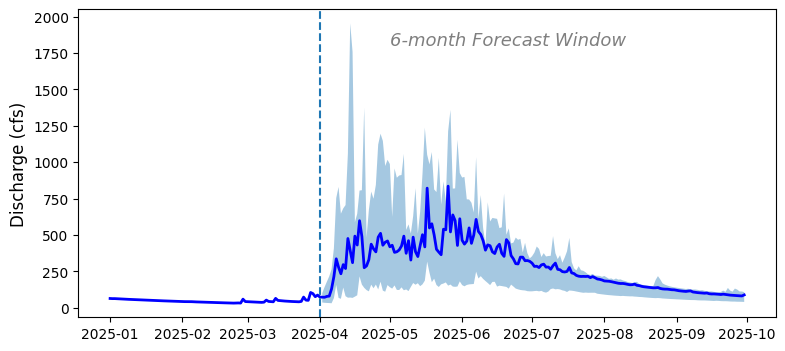

In [545]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.plot(forecast.index, forecast.median(axis=1), marker=None, ls='-', lw=2.0, color='blue')
ax.fill_between(forecast['2025-04-02':].index, forecast['2025-04-02':].quantile(0.1, axis=1), forecast['2025-04-02':].quantile(0.9, axis=1), alpha=0.4)
ax.axvline(dt.datetime(2025, 4, 1), linestyle='--')
ax.text(dt.datetime(2025, 5, 1), 1800, '6-month Forecast Window', fontstyle='italic', fontsize=13, alpha=0.5)
ax.set_ylabel('Discharge (cfs)', fontsize=12)

In [535]:
forecast['2025-04-02':].quantile(0.02, axis=1)

time
2025-04-02     9.52800
2025-04-03     9.10850
2025-04-04     8.90982
2025-04-05     8.74638
2025-04-06     8.45839
                ...   
2025-09-26    10.77883
2025-09-27    10.58811
2025-09-28    10.57155
2025-09-29    10.47024
2025-09-30    10.31262
Name: 0.02, Length: 182, dtype: float64

In [21]:
strm_df = strm.to_dataframe()
obs_df = mod.to_dataframe()

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\xarray\core\dataset.py:6257: DeprecationWarning: `cumproduct` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `cumprod` instead.
  index = self.coords.to_index([*ordered_dims])


In [97]:
lake_coef = 0.035
lake_init = 0.0
init_lake_inflow = 600
lin_route_df = pd.DataFrame({'lake_in': obs_df['sub_inq']}, index=obs_df.index)
lin_route_df['lake_in_t_1'] = lin_route_df['lake_in'].shift(1)
lin_route_df.loc[lin_route_df.index[0], 'lake_in_t_1'] = init_lake_inflow
lin_route_df['avin'] = (lin_route_df['lake_in'] + lin_route_df['lake_in_t_1']) * 0.5
lin_route_df['lake_stor'] = 0.0

stor_list = [lake_init]
for i in range(len(lin_route_df)):
    if i == 0:
        continue 
    avin = lin_route_df.loc[lin_route_df.index[i], 'avin']
    stor = lin_route_df.loc[lin_route_df.index[i], 'lake_stor']
    dS = lin_route_df.loc[lin_route_df.index[i-1], 'avin'] - (lake_coef * stor_list[i-1])
    S = stor_list[i-1] + dS
    stor_list.append(S)
lin_route_df['lake_stor'] = stor_list

lin_route_df['lake_out'] = (1 - ((1 - np.exp(-lake_coef))/(lake_coef))) * lin_route_df['avin'] + (1 - np.exp(-lake_coef)) * lin_route_df['lake_stor'].shift(1)
lin_route_df['gage'] = strm_df['observation_data'].values

In [67]:
lake_coef * lin_route_df.loc[lin_route_df.index[2], 'lake_stor']

53.52332749999999

In [88]:
lin_route_df

,lake_in,lake_in_t_1,avin,lake_stor,lake_out,gage
time,,,,,,
2020-01-01,604.7585,600.0000,602.37925,0.000000,NaN,374.00
2020-01-02,586.1839,604.7585,595.47120,602.379250,28.805431,372.00
2020-01-03,580.7035,586.1839,583.44370,1137.612525,85.547576,372.00
2020-01-04,573.0340,580.7035,576.86875,1607.294973,136.163698,372.00
2020-01-05,563.1490,573.0340,568.09150,2023.434225,180.435300,369.00
...,...,...,...,...,...,...
2024-12-27,389.0222,394.5340,391.77810,3569.988268,354.826741,405.99
2024-12-28,408.2588,389.0222,398.64050,3604.767541,359.013209,401.89
2024-12-29,1198.9502,408.2588,803.60450,3642.931287,381.912696,401.45


<Axes: xlabel='time'>

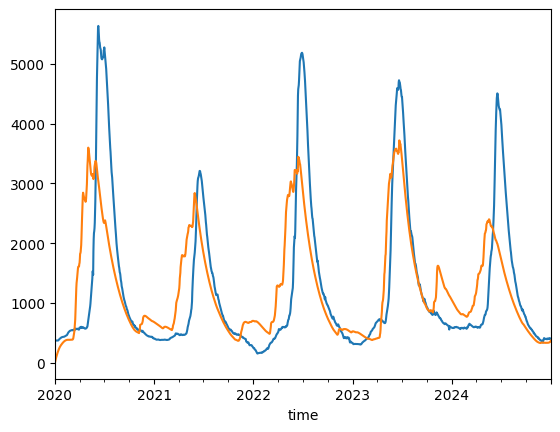

In [98]:
ax = plt.axes()
lin_route_df['gage'].plot(ax=ax)
lin_route_df['lake_out'].plot(ax=ax)
#lin_route_df['lake_in'].plot(ax=ax)

In [141]:
import numpy as np
subbasins = np.arange(1, len(obds.location)+1)

In [142]:
out_ts = []
for s in subbasins:
    vals = subout.sub_inq.sel(subbasin=s).values
    out_ts.append(vals.tolist())

In [149]:
out_obs = []
for s in subbasins:
    loc = obds.location[obds.subbasin == s]
    vals = obds.observation_data.sel(location=loc.values).values.ravel()
    out_obs.append(vals.tolist())

In [151]:
s, e = np.array(out_ts), np.array(out_obs)

In [155]:
mean_observed = np.nanmean(e)
# compute numerator and denominator
numerator = np.nansum((e - s) ** 2)
denominator = np.nansum((e - mean_observed) ** 2)
1 - (numerator / denominator)

0.1564884033526206

In [12]:
gmet_cf = xr.open_dataset(gmet_sradcf_pth)
gmet_cf = gmet_cf.rename_dims({'FID':'hru'})
gmet_cf.correction_factor[-1,:] = gmet_cf.correction_factor[-2,:]

In [13]:
cor_gmetsr = gmet_sr.shortwave_solarrad * gmet_cf.correction_factor

In [43]:
cor_gmetsr

<xarray.DataArray (time: 1827, hru: 45244)>
array([[16.5032573 , 18.57329131, 19.38564936, ..., 17.65943201,
        17.37569904, 19.73257739],
       [10.60316368, 11.2143289 , 11.70229321, ..., 11.48204545,
        11.21983437, 15.64233912],
       [11.48120717, 12.74003964, 13.31749139, ..., 12.45622648,
        12.14715291, 15.97943159],
       ...,
       [12.53750955, 14.0705649 , 14.72059921, ..., 15.24957923,
        15.15342724, 16.47183009],
       [16.26321156, 18.41897207, 19.22766789, ..., 14.94955392,
        14.86681065, 15.35466677],
       [10.51849517, 11.54215274, 12.04891776, ..., 13.88510784,
        13.69004834, 15.85663324]])
Coordinates:
  * hru      (hru) int32 1 2 3 4 5 6 7 ... 45239 45240 45241 45242 45243 45244
  * time     (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31

In [14]:
gmet_srmn = cor_gmetsr.mean(dim='hru')

In [16]:
out = PrmsOutput(prmscont)

<Axes: xlabel='Date'>

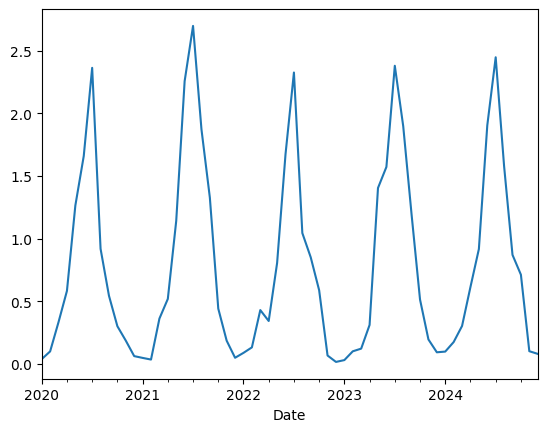

In [21]:
out.selected_variables['hru_actet_25501'].resample('MS').sum().plot()

In [14]:
res_converted = out.selected_variables['swrad_25501'] * 0.484583

In [16]:
res_converted.to_list()

[23.945804143657,
 24.071051888752,
 24.208224736894,
 24.357297974349997,
 24.518244464471998,
 24.691033193947998,
 24.875633634049,
 25.072007502717998,
 25.280108279986997,
 25.499895745467,
 25.731317564194,
 25.974324793284996,
 26.228853467784,
 26.494844953148,
 26.772225592761,
 27.060931906249998,
 27.36087909159,
 27.67198622342,
 27.994169953464,
 28.32733142679,
 28.671377603462,
 29.026204298135,
 29.391702964217,
 29.767758270953998,
 30.154250526345,
 30.551055677142,
 30.958042401352,
 31.375078407815995,
 31.802012506637997,
 32.23871095291,
 32.685014803408,
 33.140764145742004,
 33.605804397935,
 34.079968863435,
 34.563076792783,
 35.054954220682,
 35.555423789754,
 36.064296512629,
 36.581380494438996,
 37.106483355733,
 37.639402056234005,
 38.179939855244,
 38.727890804988,
 39.283047503942,
 39.845187528509,
 40.41410105425,
 40.989569049649,
 41.571370544858,
 42.159286508361,
 42.753084824900995,
 43.352536286719,
 43.957417985635,
 44.567498290975,
 45.18254

In [62]:
prms_srad = out.get_basin_output() * 0.484583

<Axes: xlabel='time'>

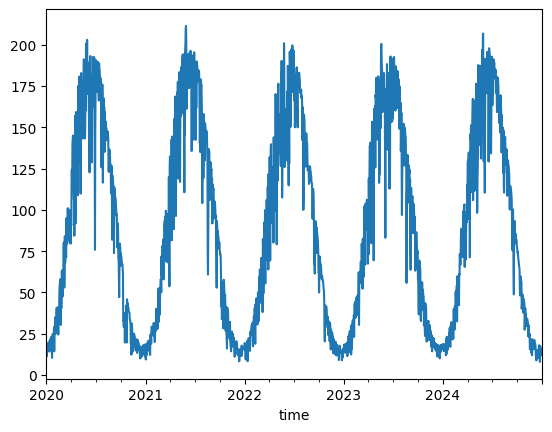

In [17]:
gmet_srmn.to_pandas().plot()

<Axes: xlabel='Date'>

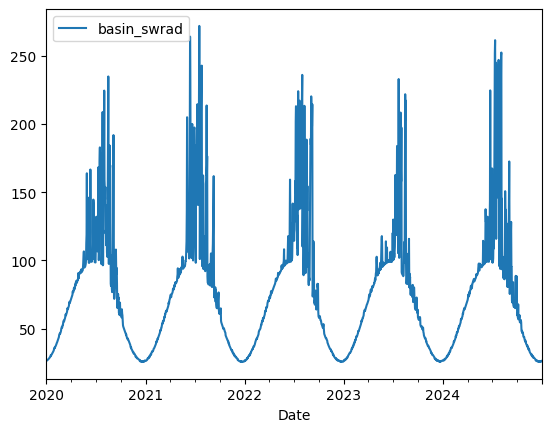

In [63]:
prms_srad.plot()

# Segments Run

In [92]:
yllake_data_pth = Path('C:/Users/CNB968/OneDrive - MT/Yellowstone/Upper Yellowstone/Yellowstone_Lake_Outlet_Flow.csv')
yllake_data = pd.read_csv(yllake_data_pth, parse_dates=True, index_col=0)

In [93]:
yllake_data

,00060_Mean
datetime,
1979-01-01,370.0
1979-01-02,360.0
1979-01-03,350.0
1979-01-04,350.0
1979-01-05,360.0
...,...
2025-07-16,2350.0
2025-07-17,2310.0
2025-07-18,2250.0


In [176]:
prmscont = pprms.CreateControlFile(prms_exe=Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'),
                               prms_version='6.0.0',
                               start_time='2018-01-01',
                               end_time='2024-12-31',
                               data_files=m_wd / 'UYnolake_1979_2025.data',
                               param_files=m_wd / 'UY_nolake_params.param',
                               output_path=m_wd,
                               file_name='UY_nolake_segments.control')
prmscont.select_output_variables(['seg_inflow', 'seg_outflow', 'strm_seg_in', 'seg_upstream_inflow'])

In [177]:
prmscont.control_obj.set_values('strmflow_module', ['strmflow_in_out'])

In [178]:
prmscont.control_obj.get_values('strmflow_module')

array(['strmflow_in_out'], dtype='<U15')

In [179]:
prmscont.save_controlfile()

In [180]:
segmod = PrmsModel(prmscont)

------------------------------------
Reading parameter file : UY_nolake_params.param
------------------------------------


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [94]:
yllake_data = yllake_data.reindex(pd.date_range('1979-01-01', '2025-04-01'))
yllake_data = yllake_data.interpolate()

In [98]:
segmod.data.data_df['runoff_0'] = yllake_data['1979-01-01': '2025-04-01'].values

In [99]:
cols = segmod.data.data_df.columns[:-2].to_list() + [segmod.data.data_df.columns[-1]] + [segmod.data.data_df.columns[-2]]
segmod.data.data_df = segmod.data.data_df[cols]

In [101]:
write_prms_datafile(segmod.data, m_wd / segmod.data.name)

In [30]:
segmod.parameters.change_parameter('obsout_lake', 1)

In [53]:
segmod.parameters.change_parameter('lake_type', 3)

In [54]:
segmod.parameters.change_parameter('hru_type', 1)

In [55]:
segmod.parameters.change_parameter('segment_type', 0)

In [132]:
segmod.parameters.change_parameter('obsin_segment', values=0, dim='nsegment', idx={'nsegment': 399})

In [133]:
segmod.parameters.change_parameter('obsout_segment', values=0, dim='nsegment', idx={'nsegment': 399})

In [134]:
segmod.parameters.change_parameter('segment_type', values=0, dim='nsegment', idx={'nsegment': 399})

In [65]:
segmod.parameters.remove_parameters('lake_hru_id')

In [68]:
segmod.parameters.remove_parameters('lake_segment_id')

In [113]:
segmod.parameters.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nssr: 46199, ngw: 46199, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw, ndeplval
Data variables: (12/108)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    melt_look             (nhru) int32 90 90 90 90 90 90 ... 90 90 90 90 90 90
    settle_const          (nhru) float64 0.1 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    snarea_thresh         (nhru) float64 50.0 50.0 50.0 50.0 ... 50.0 50.0 50.0
    cecn_coef             (nmonths, nhru) float64 5.0 5.0 5.0 ... 5.0 5.0 5.0
    tstorm_mo             (nmonths, nhru) int32 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [119]:
t = segmod.data.data_df['runoff_0']

In [122]:
t[t < 0]

Series([], Name: runoff_0, dtype: float64)

In [135]:
segmod.parameters.write_paramfile()

In [181]:
segmod.run_model()



                         U.S. Geological Survey
               Precipitation-Runoff Modeling System (PRMS)
                        Version 6.0.0 02/01/2025

--------------------------------------------------------------------
        Process            Available Modules
--------------------------------------------------------------------
  Basin Definition: basin
    Cascading Flow: cascade
  Time Series Data: obs, water_use_read, dynamic_param_read
                    dynamic_soil_param_read
   Potet Solar Rad: soltab
  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,
                    temp_map
       Precip Dist: precip_1sta, precip_laps, precip_dist2,
                    climate_hru, precip_map
Temp & Precip Dist: xyz_dist, ide_dist
    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru
Transpiration Dist: transp_tindex, climate_hru, transp_frost
      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,
                    potet_hs, potet_pt, potet_pm, pote

(True,
 ['',
  '',
  '                         U.S. Geological Survey',
  '               Precipitation-Runoff Modeling System (PRMS)',
  '                        Version 6.0.0 02/01/2025',
  '',
  '--------------------------------------------------------------------',
  '        Process            Available Modules',
  '--------------------------------------------------------------------',
  '  Basin Definition: basin',
  '    Cascading Flow: cascade',
  '  Time Series Data: obs, water_use_read, dynamic_param_read',
  '                    dynamic_soil_param_read',
  '   Potet Solar Rad: soltab',
  '  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,',
  '                    temp_map',
  '       Precip Dist: precip_1sta, precip_laps, precip_dist2,',
  '                    climate_hru, precip_map',
  'Temp & Precip Dist: xyz_dist, ide_dist',
  '    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru',
  'Transpiration Dist: transp_tindex, climate_hru, transp_frost',
  '      

In [182]:
output = PrmsOutput(prmscont, obs_dset=obds)

In [183]:
segout = output.get_segment_output()

In [184]:
segout = segout.sel(time=slice('2020-01-01', '2024-12-31'))
#segout = subout.assign_coords(subbasin=subout['subbasin'].values.astype(int))

In [20]:
obds

<xarray.Dataset>
Dimensions:           (time: 1827, location: 18)
Coordinates:
    lon               (location) float64 -110.4 -110.4 -110.7 ... -110.6 -110.8
    lat               (location) float64 44.58 44.93 44.99 ... 45.56 45.6 45.11
    hru               (location) int64 6784 38742 11433 ... 23540 18922 31608
  * location          (location) object '06186500' '06188000' ... '06191500'
  * time              (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
    subbasin          (location) int64 16 1 15 4 3 5 6 13 ... 9 2 12 11 10 18 17
    segment           (location) int64 400 162 137 1241 ... 954 1218 1086 522
Data variables:
    observation_data  (time, location) float64 374.0 155.0 110.0 ... 87.51 411.0
Attributes:
    description:  Observation data associated with PRMS model domain.

In [159]:
segout

<xarray.Dataset>
Dimensions:              (time: 1827, segment: 1352)
Coordinates:
  * segment              (segment) int32 1 2 3 4 5 ... 1348 1349 1350 1351 1352
  * time                 (time) datetime64[ns] 2020-01-01 ... 2024-12-31
Data variables:
    seg_inflow           (time, segment) float64 14.19 0.1982 ... 106.1 112.7
    seg_outflow          (time, segment) float64 14.45 0.2002 ... 105.2 111.5
    strm_seg_in          (time, segment) float64 0.0293 0.0018 ... 0.0028 0.0
    seg_upstream_inflow  (time, segment) float64 14.16 0.1964 ... 106.1 112.7

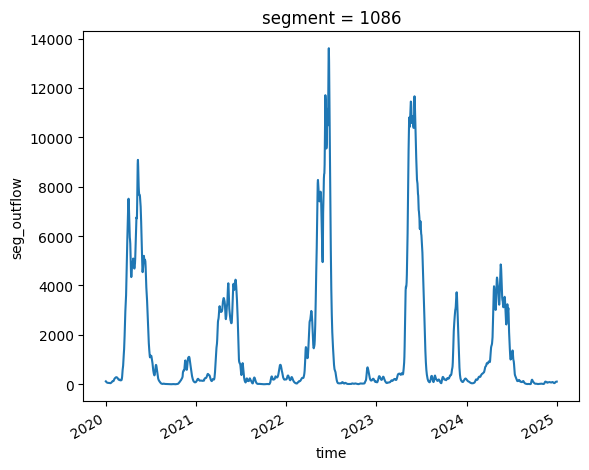

In [167]:
ax = plt.axes()
segout.seg_outflow.sel(segment=1086).plot(ax=ax)
#segout.strm_seg_in.sel(segment=155).plot(ax=ax)

In [156]:
obds.location.values

array(['06186500', '06188000', '06191000', '43B 89500', '43B 89480',
       '43B 91550', '43B 91620', '43B 01990', '43B 91750', '43B 91820',
       '43B 02950', '43B 02990', '43B 05950', '43B 05990', '43B 09550',
       '43B 09510', '06192500', '06191500'], dtype=object)

In [146]:
obds.subbasin.values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [147]:
obds.segment.values

array([ 400,  157,  133, 1241,  899, 1204, 1124,  733,  480,  617, 1084,
        939,  644,  584,  954, 1218, 1086,  522])

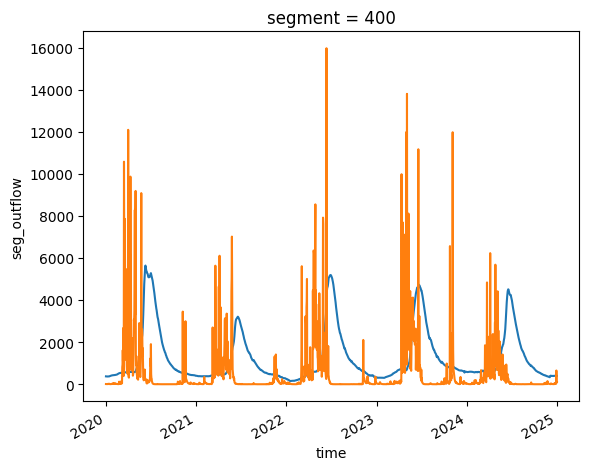

In [189]:
segid = 400
loc = obds.location[obds.segment == segid]
strm = obds.observation_data.sel(location=loc.values)
mod = segout.seg_outflow.sel(segment=segid)
#mod2 = subout.sub_cfs.sel(subbasin=subbsn)

import matplotlib.pyplot as plt

ax = plt.axes()
strm.sel().plot(ax=ax)
mod.sel().plot(ax=ax)

In [173]:
bsn_out = output.summary_csv[('basin_cfs', 'cfs')]

<Axes: xlabel='Date'>

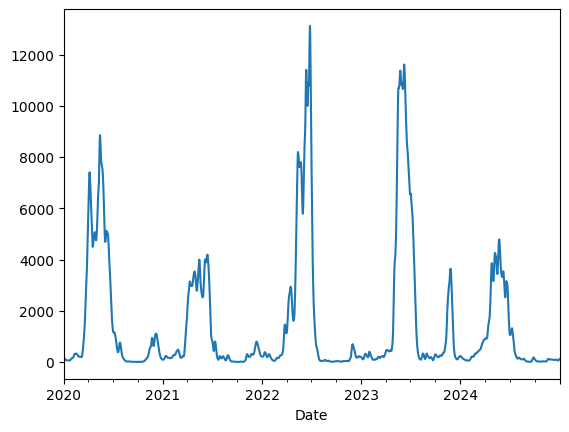

In [175]:
bsn_out['2020-01-01':'2024-12-31'].plot()

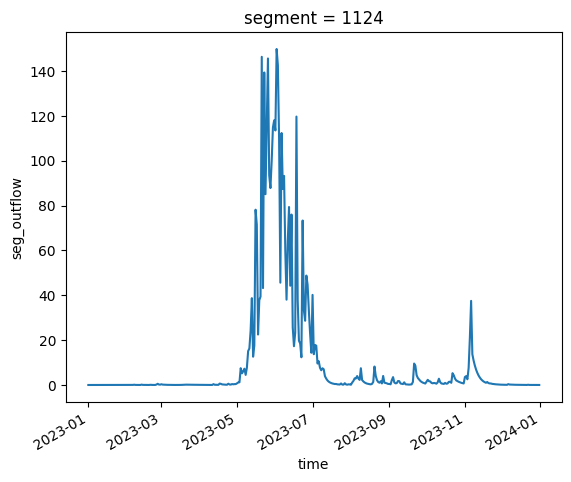

In [42]:
mod.sel(time=slice('2023-01-01', '2023-12-31')).plot()